# Instituto Superior de Engenharia do Porto (ISEP)
## Departamento de Engenharia Electrotécnica
### Unidade Curricular: Sinais e Sistemas (SINSI)

---
# Resolução Detalhada de Exercícios Selecionados (TP03)

**Tópicos Abordados:**
1. Transformações da Variável Independente (Tempo Contínuo e Tempo Discreto)
2. Derivada Generalizada e Funções Singulares (Degrau de Heaviside e Impulso de Dirac)
3. Propriedades e Cálculo Integral com Funções Singulares

---
### Guia de Estudo e Estrutura do Notebook
Este caderno prático foi concebido com rigor pedagógico e formalismo matemático para consolidar os conceitos de base da análise de sinais:
* **Enquadramento Teórico Formal:** Revisão aprofundada dos conceitos, teoremas e propriedades matemáticas.
* **Resolução Analítica Passo a Passo:** Dedução matemática explícita de todos os exercícios da ficha TP03.
* **Simulação e Computação em Python:** Validação gráfica com `NumPy`/`Matplotlib` e computação simbólica analítica com `SymPy`.


In [11]:
# Configuração do ambiente e importação das bibliotecas essenciais
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Configuração de estilo visual rigoroso para engenharia
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 110
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'

# Inicialização da impressão em formato LaTeX no SymPy
sp.init_printing(use_latex=True)
print("Ambiente configurado com sucesso! Bibliotecas prontas: NumPy, Matplotlib, SymPy.")


Ambiente configurado com sucesso! Bibliotecas prontas: NumPy, Matplotlib, SymPy.


---
## Secção 1: Transformações da Variável Independente

### 1.1 Enquadramento Teórico

Na análise de sinais e sistemas em Engenharia Electrotécnica, as transformações da variável independente (tempo contínuo $t$ ou tempo discreto $n$) são a base para a modelação de fenómenos físicos reais, tais como:
* **Atrasos de propagação** em linhas de transmissão e canais de comunicação;
* **Mudanças de velocidade** de reprodução / variação da taxa de relógio (*clock*);
* **Amostragem, multiplexagem** e processamento digital de sinal.

---

#### A. Sinais em Tempo Contínuo: Transformação Afim $y(t) = x(at + b)$
Dada uma função temporal $x(t)$, a transformação geral afim $y(t) = x(at + b)$ (com $a, b \in \mathbb{R}$ e $a \neq 0$) envolve:

1. **Deslocamento Temporal (*Time Shifting*): $x(t + b)$**
   * Se $b > 0$: **Avanço temporal** (*time advance*), o sinal é transladado para a **esquerda** em $|b|$ segundos (o evento ocorre mais cedo).
   * Se $b < 0$: **Atraso temporal** (*time delay*), o sinal é transladado para a **direita** em $|b|$ segundos (o evento ocorre mais tarde).

2. **Escala Temporal (*Time Scaling*): $x(at)$**
   * Se $|a| > 1$: **Compressão temporal** (*compression*), o sinal ocorre mais rapidamente (fator de aceleração $|a|$).
   * Se $0 < |a| < 1$: **Expansão temporal** (*expansion*), o sinal sofre um abrandamento.

3. **Inversão Temporal (*Time Reversal*): $x(-t)$**
   * Se $a < 0$: Ocorre uma reflexão geométrica em torno do eixo vertical $t=0$.

> **Regra de Ouro do Mapeamento de Pontos Notáveis:**  
> Para evitar ambiguidades na ordem das operações (escala vs deslocamento), determine a nova posição $t$ de qualquer instante original $t_0$ resolvendo o argumento:
> $$at + b = t_0 \implies t = \frac{t_0 - b}{a}$$

---

#### B. Sinais em Tempo Discreto: Particularidades e Decimação
Para um sinal discreto $x[n]$ com $n \in \mathbb{Z}$:
1. **Deslocamento:** $x[n - n_0]$ com $n_0 \in \mathbb{Z}$.
2. **Decimação / Subamostragem (*Downsampling*):** $x[Mn]$ com $M \in \mathbb{Z}^+$ ($M > 1$).
   * *Atenção:* Em tempo discreto, $x[Mn]$ **descarta/elimina todas as amostras cujos índices não sejam múltiplos inteiros de $M$**.
3. **Inversão e Deslocamento:** $x[-n + n_0] = x[-(n - n_0)]$.


### Exercício 10 — Transformações em Tempo Contínuo

**Enunciado:**  
Considere o sinal $x(t)$ definido por:
$$x(t) = \begin{cases} t+1, & -1 \le t \le 0 \\ 1, & 0 < t < 2 \\ 0, & \text{outros valores} \end{cases}$$

Obtenha a expressão analítica e represente graficamente os seguintes sinais:
* **b)** $x_2(t) = x(t+3)$
* **d)** $x_4(t) = x(2t)$
* **e)** $x_5(t) = x(t/3)$
* **f)** $x_6(t) = x(t/3+3)$

---

#### Resolução Analítica Detalhada:

1. **Sinal Original $x(t)$:**
   * Intervalo 1: $t \in [-1, 0] \implies x(t) = t+1$ (rampa linear que sobe de 0 até 1).
   * Intervalo 2: $t \in ]0, 2[ \implies x(t) = 1$ (patamar horizontal constante).
   * Restantes valores: $x(t) = 0$.

---

2. **Alínea b) $x_2(t) = x(t+3)$ — Avanço Temporal de 3 unidades ($\Delta t = -3$):**
   * Fazendo a substituição de variável $u = t+3$:
     * Ramo linear: $-1 \le t+3 \le 0 \iff -4 \le t \le -3$, com $(t+3)+1 = t+4$.
     * Ramo constante: $0 < t+3 < 2 \iff -3 < t < -1$, com valor $1$.
   * **Expressão Analítica Final:**
     $$x_2(t) = \begin{cases} t+4, & -4 \le t \le -3 \\ 1, & -3 < t < -1 \\ 0, & \text{outros valores} \end{cases}$$

---

3. **Alínea d) $x_4(t) = x(2t)$ — Compressão Temporal por Fator 2:**
   * Fazendo $u = 2t$:
     * Ramo linear: $-1 \le 2t \le 0 \iff -0.5 \le t \le 0$, com $2t+1$.
     * Ramo constante: $0 < 2t < 2 \iff 0 < t < 1$, com valor $1$.
   * **Expressão Analítica Final:**
     $$x_4(t) = \begin{cases} 2t+1, & -0.5 \le t \le 0 \\ 1, & 0 < t < 1 \\ 0, & \text{outros valores} \end{cases}$$

---

4. **Alínea e) $x_5(t) = x(t/3)$ — Expansão Temporal por Fator 3:**
   * Fazendo $u = t/3$:
     * Ramo linear: $-1 \le t/3 \le 0 \iff -3 \le t \le 0$, com $\frac{t}{3}+1$.
     * Ramo constante: $0 < t/3 < 2 \iff 0 < t < 6$, com valor $1$.
   * **Expressão Analítica Final:**
     $$x_5(t) = \begin{cases} \frac{t}{3}+1, & -3 \le t \le 0 \\ 1, & 0 < t < 6 \\ 0, & \text{outros valores} \end{cases}$$

---

5. **Alínea f) $x_6(t) = x(t/3+3)$ — Expansão e Avanço Temporal:**
   * Mapeamento dos pontos notáveis: $\frac{t}{3}+3 = u \implies t = 3(u - 3) = 3u - 9$.
     * $u = -1 \implies t = 3(-1) - 9 = -12$
     * $u = 0 \implies t = 3(0) - 9 = -9$
     * $u = 2 \implies t = 3(2) - 9 = -3$
   * Ramo linear: $-12 \le t \le -9$, com $\left(\frac{t}{3}+3\right)+1 = \frac{t}{3}+4$.
   * Ramo constante: $-9 < t < -3$, com valor $1$.
   * **Expressão Analítica Final:**
     $$x_6(t) = \begin{cases} \frac{t}{3}+4, & -12 \le t \le -9 \\ 1, & -9 < t < -3 \\ 0, & \text{outros valores} \end{cases}$$


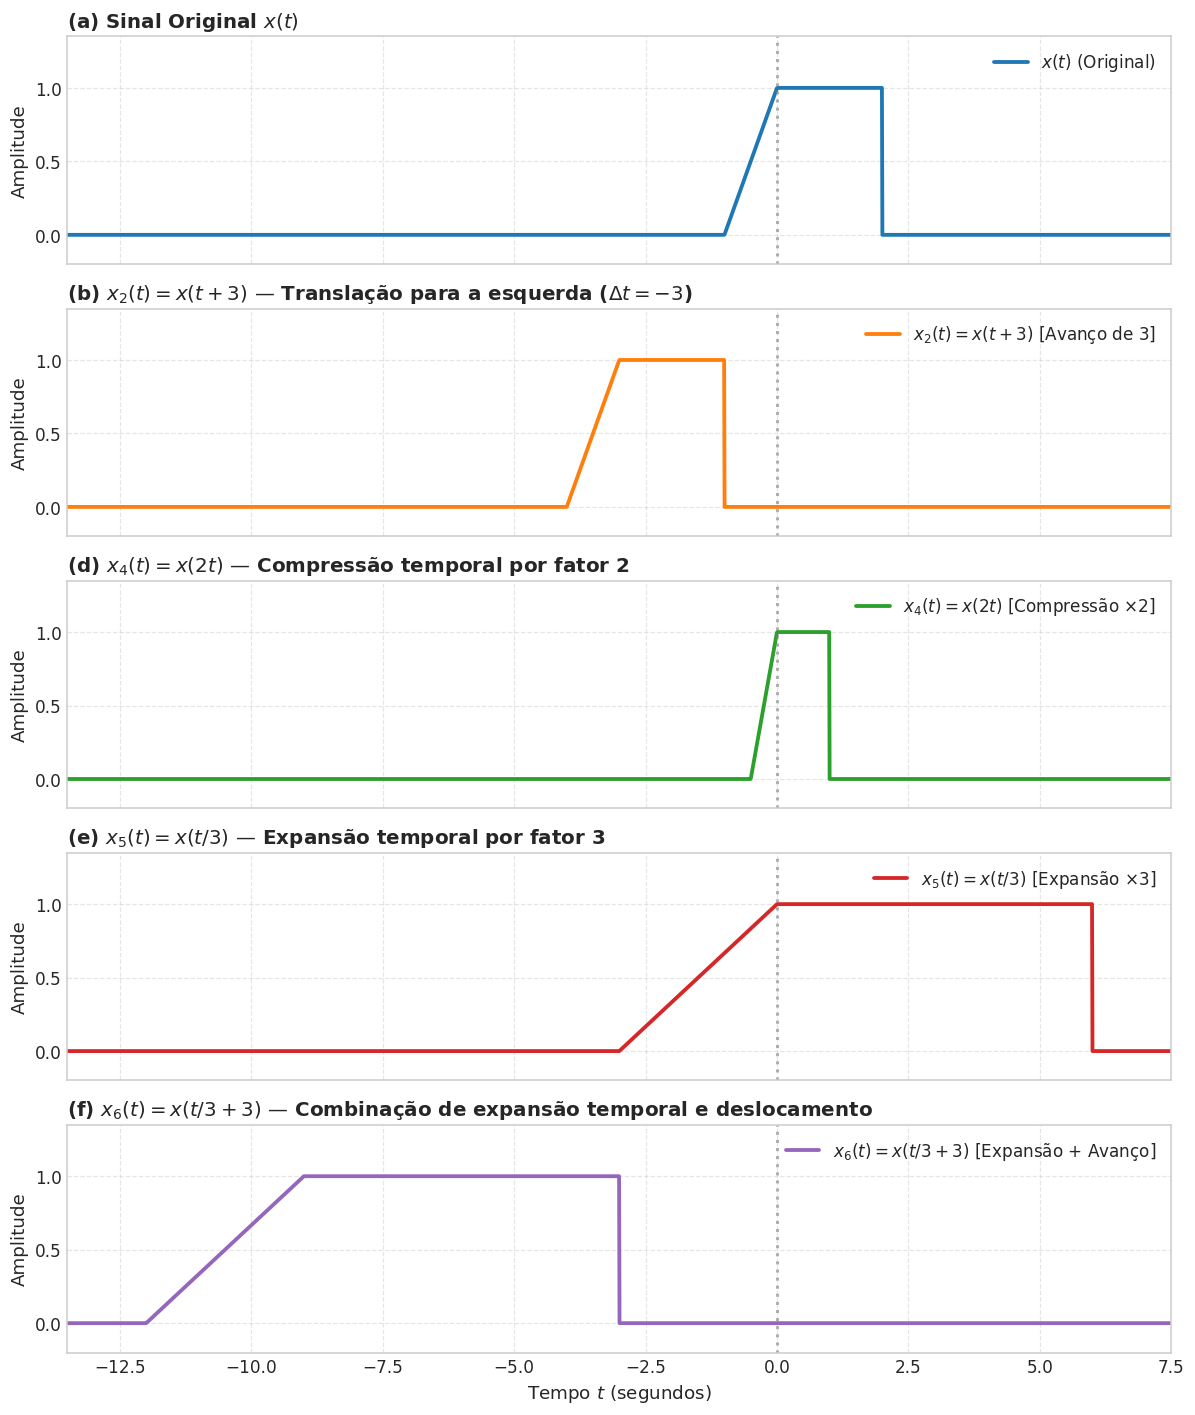

In [12]:
# Código de Simulação e Visualização Gráfica do Exercício 10
def x_orig(t):
    cond_rampa = (t >= -1.0) & (t <= 0.0)
    cond_const = (t > 0.0) & (t < 2.0)
    return np.piecewise(t, [cond_rampa, cond_const], [lambda t: t + 1.0, 1.0, 0.0])

t_vec = np.linspace(-14, 8, 2500)

x_base = x_orig(t_vec)
x2 = x_orig(t_vec + 3.0)        # x(t+3)
x4 = x_orig(2.0 * t_vec)        # x(2t)
x5 = x_orig(t_vec / 3.0)        # x(t/3)
x6 = x_orig(t_vec / 3.0 + 3.0)  # x(t/3+3)

fig, axs = plt.subplots(5, 1, figsize=(11, 13), sharex=True)

axs[0].plot(t_vec, x_base, color='#1f77b4', lw=2.5, label=r'$x(t)$ (Original)')
axs[0].set_title(r'(a) Sinal Original $x(t)$', loc='left', fontweight='bold')
axs[0].legend(loc='upper right')

axs[1].plot(t_vec, x2, color='#ff7f0e', lw=2.5, label=r'$x_2(t) = x(t+3)$ [Avanço de 3]')
axs[1].set_title(r'(b) $x_2(t) = x(t+3)$ — Translação para a esquerda ($\Delta t = -3$)', loc='left', fontweight='bold')
axs[1].legend(loc='upper right')

axs[2].plot(t_vec, x4, color='#2ca02c', lw=2.5, label=r'$x_4(t) = x(2t)$ [Compressão $\times 2$]')
axs[2].set_title(r'(d) $x_4(t) = x(2t)$ — Compressão temporal por fator 2', loc='left', fontweight='bold')
axs[2].legend(loc='upper right')

axs[3].plot(t_vec, x5, color='#d62728', lw=2.5, label=r'$x_5(t) = x(t/3)$ [Expansão $\times 3$]')
axs[3].set_title(r'(e) $x_5(t) = x(t/3)$ — Expansão temporal por fator 3', loc='left', fontweight='bold')
axs[3].legend(loc='upper right')

axs[4].plot(t_vec, x6, color='#9467bd', lw=2.5, label=r'$x_6(t) = x(t/3+3)$ [Expansão + Avanço]')
axs[4].set_title(r'(f) $x_6(t) = x(t/3+3)$ — Combinação de expansão temporal e deslocamento', loc='left', fontweight='bold')
axs[4].set_xlabel('Tempo $t$ (segundos)')
axs[4].legend(loc='upper right')

for ax in axs:
    ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
    ax.set_ylim(-0.2, 1.35)
    ax.set_ylabel('Amplitude')
    ax.set_xlim(-13.5, 7.5)

plt.tight_layout()
plt.show()


### Exercício 11 — Representação Analítica com Degraus de Heaviside

**Enunciado:**  
Represente graficamente e analiticamente o sinal $x(t)$ com amplitude $2$ entre os instantes $0 < a < b$ e $0$ para outros valores de tempo.

---

#### Resolução Analítica:

1. **Definição Seccionada (Por Ramos):**
   $$x(t) = \begin{cases} 2, & a \le t \le b \\ 0, & \text{caso contrário} \end{cases}$$

2. **Representação com Degraus Unitários de Heaviside $u(t)$:**
   Em engenharia de controlo e telecomunicações, as funções singulares facilitam a obtenção de Transformadas de Laplace e Fourier.
   * O início do pulso no instante $t = a$ com amplitude $2$ é modelado por: $+2 u(t - a)$.
   * O término do pulso no instante $t = b$ é efetuado pela subtração de um degrau de igual amplitude: $-2 u(t - b)$.
   * **Expressão Canónica Compacta:**
     $$x(t) = 2 \left[ u(t - a) - u(t - b) \right]$$

3. **Métricas Físicas do Sinal:**
   * **Duração / Largura do Pulso:** $T = b - a$.
   * **Área Total (Integral):** $\int_{-\infty}^{\infty} x(t) dt = 2(b - a)$.
   * **Energia do Pulso:** $E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt = 2^2 (b - a) = 4(b - a)$.


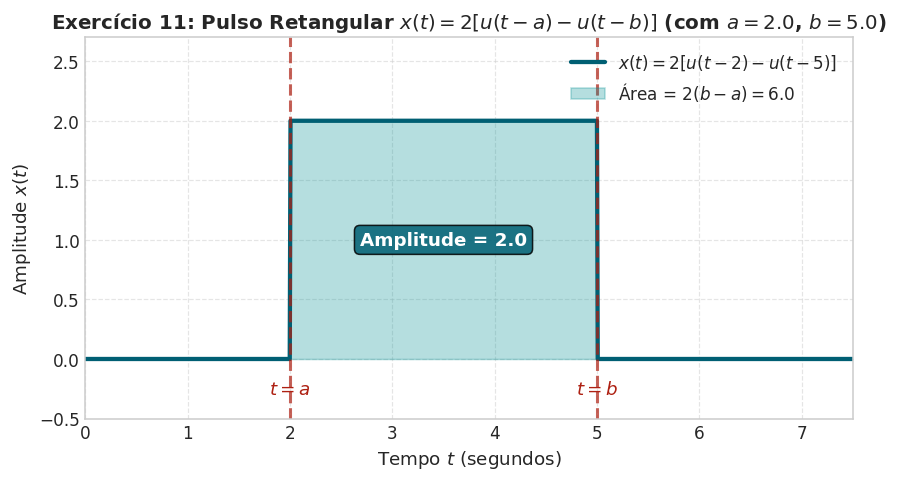

In [13]:
# Simulação e Representação Paramétrica do Exercício 11
a_param = 2.0
b_param = 5.0
amp_param = 2.0

t_axis = np.linspace(0, 7.5, 1000)

def rect_pulse(t, a, b, A=2.0):
    return A * ((t >= a) & (t <= b)).astype(float)

x_rect = rect_pulse(t_axis, a_param, b_param, amp_param)

plt.figure(figsize=(9, 4.5))
plt.plot(t_axis, x_rect, color='#005f73', lw=2.8, label=f'$x(t) = {amp_param:.0f}[u(t-{a_param:.0f}) - u(t-{b_param:.0f})]$')
plt.fill_between(t_axis, x_rect, color='#0a9396', alpha=0.3, label=f'Área = $2(b-a) = {amp_param*(b_param-a_param):.1f}$')

plt.axvline(a_param, color='#ae2012', linestyle='--', alpha=0.7)
plt.axvline(b_param, color='#ae2012', linestyle='--', alpha=0.7)
plt.text(a_param, -0.3, '$t = a$', color='#ae2012', ha='center', fontweight='bold', fontsize=12)
plt.text(b_param, -0.3, '$t = b$', color='#ae2012', ha='center', fontweight='bold', fontsize=12)
plt.text((a_param + b_param)/2, amp_param/2, f'Amplitude = {amp_param}', ha='center', va='center', 
         fontsize=12, fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='#005f73', alpha=0.85))

plt.title(f'Exercício 11: Pulso Retangular $x(t) = 2[u(t-a) - u(t-b)]$ (com $a={a_param}$, $b={b_param}$)', fontweight='bold')
plt.xlabel('Tempo $t$ (segundos)')
plt.ylabel('Amplitude $x(t)$')
plt.ylim(-0.5, 2.7)
plt.xlim(0, 7.5)
plt.legend(loc='upper right')
plt.show()


### Exercício 13 — Transformações em Tempo Discreto e Subamostragem

**Enunciado:**  
Considere a sequência $x[n]$ definida por:
$$x[n] = \begin{cases} 1, & n=1 \\ 2, & n=2 \\ 3, & n=3 \\ 3, & n=4 \\ 0, & \text{outros instantes} \end{cases}$$
Represente graficamente e determine os valores das amostras para os seguintes sinais:
* **b)** $x_2[n] = x[2n]$
* **d)** $x_4[n] = x[2-n]$

---

#### Resolução Analítica Passo a Passo:

#### 1. Alínea b) $x_2[n] = x[2n]$ (Subamostragem / Decimação por 2):
Avaliamos a sequência $x_2[n]$ para cada índice inteiro $n \in \mathbb{Z}$:
* $n = 0 \implies x_2[0] = x[2(0)] = x[0] = 0$
* $n = 1 \implies x_2[1] = x[2(1)] = x[2] = 2$
* $n = 2 \implies x_2[2] = x[2(2)] = x[4] = 3$
* Para qualquer outro $n$, $2n \notin \{1, 2, 3, 4\} \implies x_2[n] = 0$.

**Tabela de Mapeamento:**
| $n$ | $\le 0$ | $1$ | $2$ | $\ge 3$ |
| :---: | :---: | :---: | :---: | :---: |
| $2n$ | $\le 0$ | $2$ | $4$ | $\ge 6$ |
| $x_2[n] = x[2n]$ | **0** | **2** | **3** | **0** |

> **Nota Teórica:**  
> As amostras $x[1]=1$ e $x[3]=3$ foram irremediavelmente perdidas nesta operação.

---

#### 2. Alínea d) $x_4[n] = x[2-n] = x[-(n-2)]$ (Inversão e Avanço Temporal):
Avaliamos $x_4[n]$ para cada $n \in \mathbb{Z}$:
* $n = -2 \implies x_4[-2] = x[2 - (-2)] = x[4] = 3$
* $n = -1 \implies x_4[-1] = x[2 - (-1)] = x[3] = 3$
* $n = 0 \implies x_4[0] = x[2 - 0] = x[2] = 2$
* $n = 1 \implies x_4[1] = x[2 - 1] = x[1] = 1$
* Para qualquer outro $n$, $2-n \notin \{1, 2, 3, 4\} \implies x_4[n] = 0$.

**Tabela de Mapeamento:**
| $n$ | $\le -3$ | $-2$ | $-1$ | $0$ | $1$ | $\ge 2$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| $2-n$ | $\ge 5$ | $4$ | $3$ | $2$ | $1$ | $\le 0$ |
| $x_4[n] = x[2-n]$ | **0** | **3** | **3** | **2** | **1** | **0** |


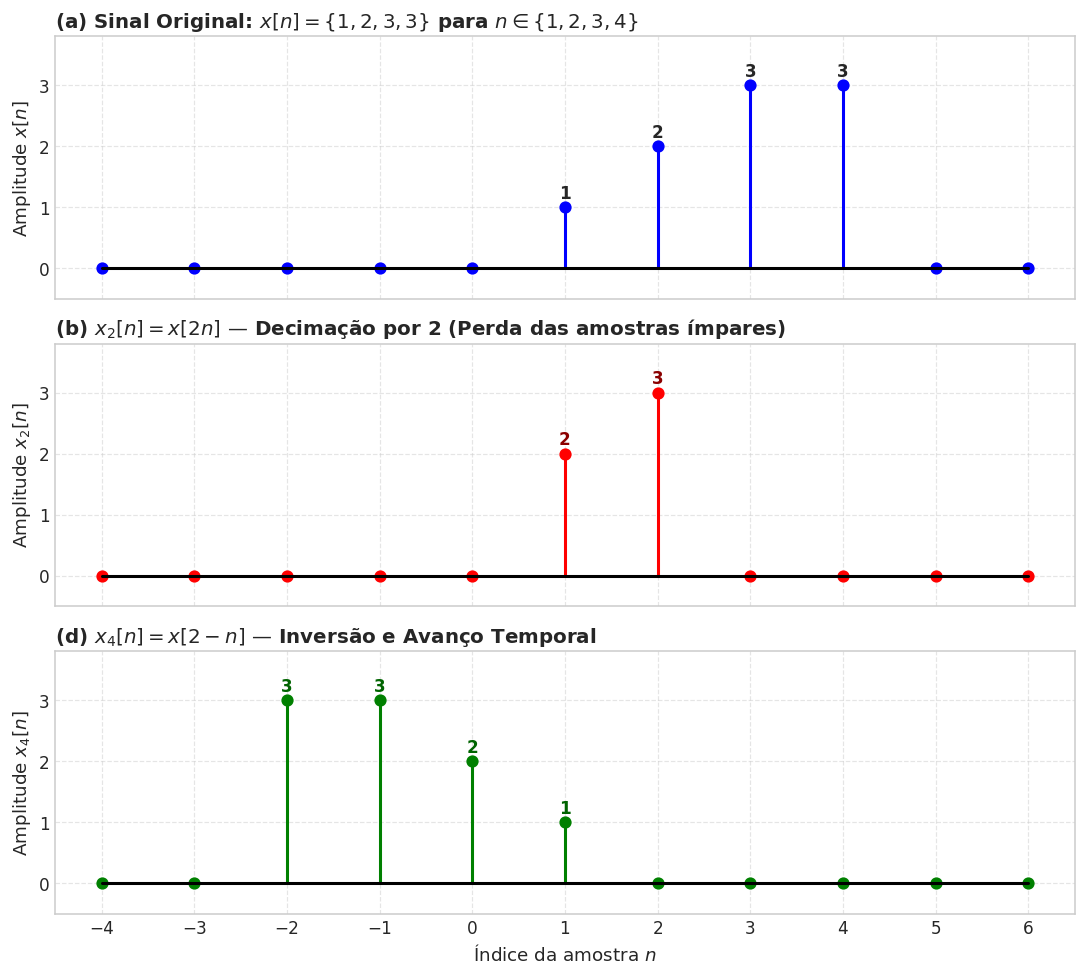

In [14]:
# Código de Simulação Discreta com Stem Plots
def x_discrete(n_arr):
    vals = {1: 1, 2: 2, 3: 3, 4: 3}
    return np.array([vals.get(int(val), 0) for val in n_arr])

n_axis = np.arange(-4, 7)

x_n = x_discrete(n_axis)
x_2n = x_discrete(2 * n_axis)
x_2minus_n = x_discrete(2 - n_axis)

fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# (a) Original
marker, stem, base = axs[0].stem(n_axis, x_n, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.setp(stem, 'linewidth', 2)
plt.setp(marker, 'markersize', 7)
axs[0].set_title(r'(a) Sinal Original: $x[n] = \{1, 2, 3, 3\}$ para $n \in \{1, 2, 3, 4\}$', loc='left', fontweight='bold')
axs[0].set_ylabel('Amplitude $x[n]$')
axs[0].set_ylim(-0.5, 3.8)
for n_v, v in zip(n_axis, x_n):
    if v > 0:
        axs[0].annotate(f'{v}', (n_v, v), textcoords="offset points", xytext=(0, 6), ha='center', fontweight='bold')

# (b) Decimação
marker, stem, base = axs[1].stem(n_axis, x_2n, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.setp(stem, 'linewidth', 2)
plt.setp(marker, 'markersize', 7)
axs[1].set_title(r'(b) $x_2[n] = x[2n]$ — Decimação por 2 (Perda das amostras ímpares)', loc='left', fontweight='bold')
axs[1].set_ylabel('Amplitude $x_2[n]$')
axs[1].set_ylim(-0.5, 3.8)
for n_v, v in zip(n_axis, x_2n):
    if v > 0:
        axs[1].annotate(f'{v}', (n_v, v), textcoords="offset points", xytext=(0, 6), ha='center', color='darkred', fontweight='bold')

# (d) Inversão e Avanço
marker, stem, base = axs[2].stem(n_axis, x_2minus_n, linefmt='g-', markerfmt='go', basefmt='k-')
plt.setp(stem, 'linewidth', 2)
plt.setp(marker, 'markersize', 7)
axs[2].set_title(r'(d) $x_4[n] = x[2-n]$ — Inversão e Avanço Temporal', loc='left', fontweight='bold')
axs[2].set_ylabel('Amplitude $x_4[n]$')
axs[2].set_xlabel('Índice da amostra $n$')
axs[2].set_ylim(-0.5, 3.8)
axs[2].set_xticks(n_axis)
for n_v, v in zip(n_axis, x_2minus_n):
    if v > 0:
        axs[2].annotate(f'{v}', (n_v, v), textcoords="offset points", xytext=(0, 6), ha='center', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Secção 2: Derivadas de Sinais e Funções Singulares

### 2.1 Enquadramento Teórico

Em circuitos elétricos e sistemas físicos, surgem descontinuidades de salto abruptas (comutação de interruptores, choques mecânicos, pulsos de relógio). 

A análise matemática destas situações baseia-se na **Teoria das Distribuições (Funções Generalizadas)**:

1. **Relação Fundamental entre Heaviside e Dirac:**
   $$\frac{d}{dt} u(t - t_0) = \delta(t - t_0)$$

2. **Derivada de Sinais Seccionados com Saltos Finitos:**
   Se um sinal $x(t)$ possui descontinuidades de salto nos instantes $t_k$, sendo $\Delta x_k = x(t_k^+) - x(t_k^-)$ o salto de amplitude, a sua derivada generalizada é expressa por:
   $$\frac{dx(t)}{dt} = \left( \frac{dx(t)}{dt} \right)_{\text{ordinária}} + \sum_{k} \Delta x_k \, \delta(t - t_k)$$

3. **Significado Físico em Engenharia Electrotécnica:**
   * Na relação constitutiva de um condensador: $i(t) = C \frac{dv(t)}{dt}$. Um salto instantâneo de tensão $\Delta V$ em $t=t_0$ induz uma corrente impulsiva $i(t) = C \Delta V \delta(t-t_0)$, transferindo uma carga finita $\Delta Q = C\Delta V$ num intervalo de tempo nulo.


### Exercício 18d — Sinal Seccionado e Derivada Generalizada

**Enunciado:**  
Represente analiticamente e graficamente o sinal e respetiva derivada para:
$$x_4(t) = 2u(t-1) - 3u(t-2) + 2u(t-4)$$

---

#### Resolução Analítica Detalhada:

#### 1. Expressão por Ramos de $x_4(t)$ e Identificação dos Saltos:
* **Para $t < 1$:**  
  Todos os degraus estão inativos $\implies x_4(t) = 0$.
* **Para $1 \le t < 2$:**  
  Apenas $u(t-1)$ está ativo $\implies x_4(t) = 2(1) = 2$.  
  *(Salto em $t=1$: $\Delta x_1 = x_4(1^+) - x_4(1^-) = 2 - 0 = +2$)*.
* **Para $2 \le t < 4$:**  
  $u(t-1)$ e $u(t-2)$ ativos $\implies x_4(t) = 2 - 3 = -1$.  
  *(Salto em $t=2$: $\Delta x_2 = x_4(2^+) - x_4(2^-) = -1 - 2 = -3$)*.
* **Para $t \ge 4$:**  
  Todos os três termos ativos $\implies x_4(t) = 2 - 3 + 2 = 1$.  
  *(Salto em $t=4$: $\Delta x_4 = x_4(4^+) - x_4(4^-) = 1 - (-1) = +2$)*.

Logo:
$$x_4(t) = \begin{cases} 0, & t < 1 \\ 2, & 1 \le t < 2 \\ -1, & 2 \le t < 4 \\ 1, & t \ge 4 \end{cases}$$

---

#### 2. Derivada Generalizada $\frac{dx_4(t)}{dt}$:
Aplicando a derivada direta aos termos em degrau:
$$\frac{dx_4(t)}{dt} = 2\delta(t-1) - 3\delta(t-2) + 2\delta(t-4)$$

* Em $t = 1$: Impulso de Dirac de peso $+2$ (seta vertical orientada para cima).
* Em $t = 2$: Impulso de Dirac de peso $-3$ (seta vertical orientada para baixo).
* Em $t = 4$: Impulso de Dirac de peso $+2$ (seta vertical orientada para cima).
* Em todos os restantes instantes, a derivada é identicamente nula.


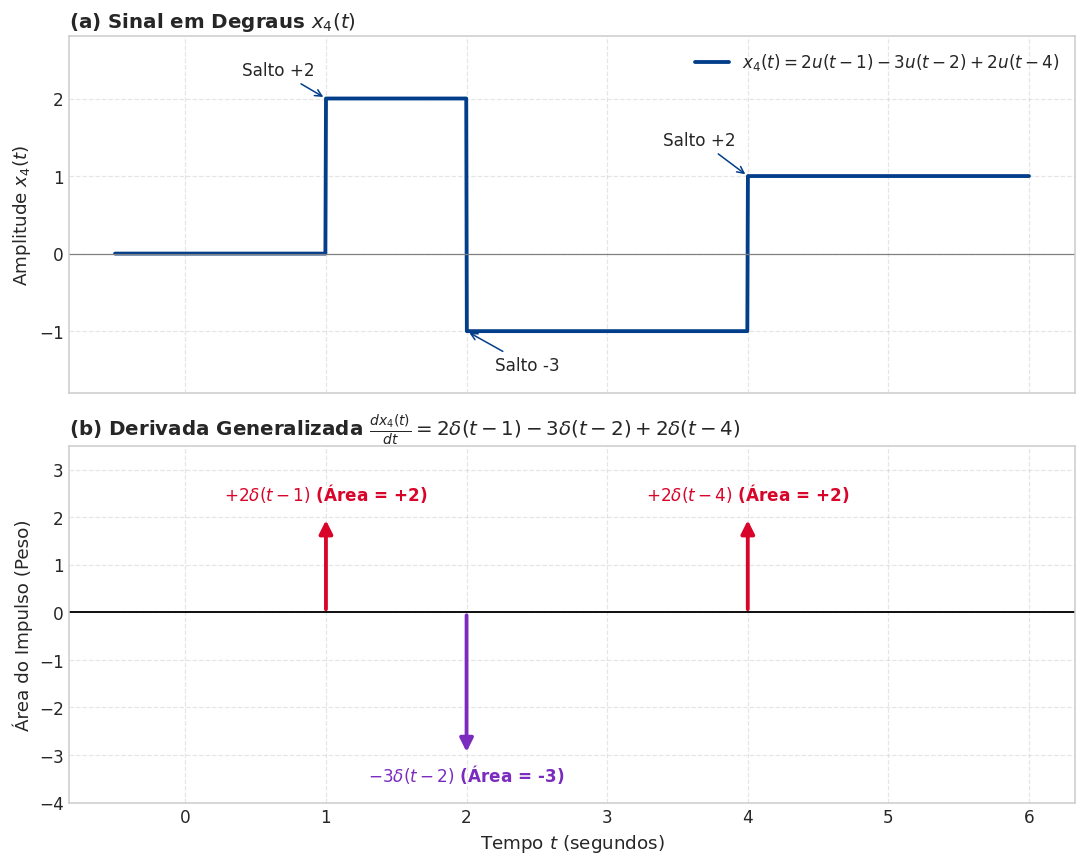

In [15]:
# Representação Gráfica Rigorosa do Exercício 18d
t_eval = np.linspace(-0.5, 6.0, 1500)

def x4_eval(t):
    return 2.0*(t >= 1.0) - 3.0*(t >= 2.0) + 2.0*(t >= 4.0)

x4_vals = x4_eval(t_eval)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico do sinal x4(t)
ax1.plot(t_eval, x4_vals, color='#023e8a', lw=2.5, label=r'$x_4(t) = 2u(t-1) - 3u(t-2) + 2u(t-4)$')
ax1.set_title(r'(a) Sinal em Degraus $x_4(t)$', fontweight='bold', loc='left')
ax1.set_ylabel('Amplitude $x_4(t)$')
ax1.set_ylim(-1.8, 2.8)
ax1.axhline(0, color='gray', linestyle='-', lw=0.8)
ax1.legend(loc='upper right')

ax1.annotate('Salto +2', xy=(1, 2), xytext=(0.4, 2.3), arrowprops=dict(arrowstyle="->", color='#023e8a'))
ax1.annotate('Salto -3', xy=(2, -1), xytext=(2.2, -1.5), arrowprops=dict(arrowstyle="->", color='#023e8a'))
ax1.annotate('Salto +2', xy=(4, 1), xytext=(3.4, 1.4), arrowprops=dict(arrowstyle="->", color='#023e8a'))

# Gráfico da Derivada Generalizada com Impulsos de Dirac
ax2.axhline(0, color='black', lw=1.2)
ax2.set_title(r'(b) Derivada Generalizada $\frac{dx_4(t)}{dt} = 2\delta(t-1) - 3\delta(t-2) + 2\delta(t-4)$', fontweight='bold', loc='left')
ax2.set_ylabel('Área do Impulso (Peso)')
ax2.set_xlabel('Tempo $t$ (segundos)')
ax2.set_ylim(-4.0, 3.5)

diracs = [
    {'t': 1.0, 'w': 2.0, 'c': '#d90429', 'lbl': r'$+2\delta(t-1)$ (Área = +2)'},
    {'t': 2.0, 'w': -3.0, 'c': '#7b2cbf', 'lbl': r'$-3\delta(t-2)$ (Área = -3)'},
    {'t': 4.0, 'w': 2.0, 'c': '#d90429', 'lbl': r'$+2\delta(t-4)$ (Área = +2)'}
]

for d in diracs:
    ax2.annotate('', xy=(d['t'], d['w']), xytext=(d['t'], 0),
                 arrowprops=dict(arrowstyle="-|>", color=d['c'], lw=2.5, mutation_scale=18))
    y_pos = d['w'] + 0.35 if d['w'] > 0 else d['w'] - 0.55
    ax2.text(d['t'], y_pos, d['lbl'], color=d['c'], ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


---
## Secção 3: Integrais e Propriedades de Funções Singulares

### 3.1 Enquadramento Teórico

As propriedades do impulso de Dirac $\delta(t)$ e do degrau de Heaviside $u(t)$ simplificam o cálculo integral em Sinais e Sistemas:

1. **Propriedade de Filtragem ou Amostragem (*Sifting Property*):**
   * Ao multiplicar por uma função contínua $f(t)$:
     $$f(t) \delta(t - t_0) = f(t_0) \delta(t - t_0)$$
   * Ao integrar em toda a reta real $\mathbb{R}$:
     $$\int_{-\infty}^{\infty} f(t) \delta(t - t_0) dt = f(t_0)$$
   * Em limites de integração finitos $[t_1, t_2]$:
     $$\int_{t_1}^{t_2} f(t) \delta(t - t_0) dt = \begin{cases} f(t_0), & \text{se } t_0 \in ]t_1, t_2[ \\ 0, & \text{se } t_0 \notin [t_1, t_2] \end{cases}$$

2. **Relação com a Função Rampa Unitária $r(t) = t \cdot u(t)$:**
   $$\int_{-\infty}^{t} u(\tau - t_0) d\tau = (t - t_0) u(t - t_0) = r(t - t_0)$$

3. **Propriedade da Área Total Unitária:**
   $$\int_{-\infty}^{\infty} \delta(t - t_0) dt = 1$$

4. **Distinção Fundamental entre Integral Definido Escalar e Função de Acumulação Temporal:**
   * **Integral com Limites Fixos (Escalar / Área Total):**
     $$\int_{-\infty}^{+\infty} \delta(\tau - t_0) d\tau = 1$$
   * **Função Primitiva / Acumulação Temporal (Sinal de Saída):**
     $$y(t) = \int_{-\infty}^{t} \delta(\tau - t_0) d\tau = u(t - t_0)$$


### Exercício 19 — Resolução Analítica dos Integrais

**Enunciado:**  
Calcule os seguintes integrais:
* **c)** $\int_{-\infty}^{\infty} (t-2)^2 \delta(t-2) dt$
* **m)** $\int_{-\infty}^{t} u(\tau-3) d\tau$
* **n)** $\int_{5}^{10} \cos(2\pi t) \delta(t-2) dt$
* **o)** $\int_{-\infty}^{\infty} [\delta(\tau+1) - \delta(\tau-1)] d\tau$

---

#### Resolução Analítica Detalhada:

#### Alínea c) $I_c = \int_{-\infty}^{\infty} (t-2)^2 \delta(t-2) dt$
* Seja $f(t) = (t-2)^2$. O impulso localiza-se em $t_0 = 2$.
* Pela propriedade de amostragem:
  $$I_c = \left. (t-2)^2 \right|_{t=2} = (2-2)^2 = 0^2 = 0$$
* **Resultado:** $I_c = 0$.

---

#### Alínea m) $I_m(t) = \int_{-\infty}^{t} u(\tau-3) d\tau$
* O integrando é $u(\tau-3) = 1$ para $\tau \ge 3$ e $0$ para $\tau < 3$.
* Distinguem-se dois casos para o limite superior $t$:
  1. Para $t < 3$: O integrando é zero em todo o percurso de integração $\implies I_m(t) = 0$.
  2. Para $t \ge 3$:
     $$I_m(t) = \int_{-\infty}^{3} 0 \, d\tau + \int_{3}^{t} 1 \, d\tau = [\tau]_3^t = t - 3$$
* **Expressão Canónica Unificada:**
  $$I_m(t) = (t-3)u(t-3) = r(t-3) \quad \text{(Rampa unitária iniciada em } t=3\text{)}$$

---

#### Alínea n) $I_n = \int_{5}^{10} \cos(2\pi t) \delta(t-2) dt$
* O impulso de Dirac $\delta(t-2)$ tem o seu suporte concentrado no ponto $t = 2$.
* O intervalo de integração é $[5, 10]$.
* Como $2 \notin [5, 10]$, o impulso é nulo em todo o domínio de integração.
* **Resultado:** $I_n = 0$.

---

#### Alínea o) $I_o = \int_{-\infty}^{\infty} [\delta(\tau+1) - \delta(\tau-1)] d\tau$

> **Nota Pedagógica de Distinção (Integral Definido vs. Função Temporal Acumulada):**

1. **O Integral Solicitado no Enunciado (Limites de $-\infty$ a $+\infty$):**
   * Pela linearidade do integral e pela propriedade da área unitária ($\int_{-\infty}^{\infty} \delta(t-t_0) dt = 1$):
     $$I_o = \int_{-\infty}^{\infty} \delta(\tau+1) d\tau - \int_{-\infty}^{\infty} \delta(\tau-1) d\tau = 1 - 1 = \mathbf{0}$$
   * **Interpretação Física:** Balanço líquido total de área/carga nulo (dois impulsos opostos de mesma intensidade).

2. **A Função Primitiva / Acumulação com Limite Superior $t$:**
   * Se o limite superior de integração fosse a variável temporal $t$, teríamos uma **função temporal $y(t)$**:
     $$y(t) = \int_{-\infty}^{t} [\delta(\tau+1) - \delta(\tau-1)] d\tau = u(t+1) - u(t-1)$$
   * Analisando $y(t)$ por intervalos:
     * Para $t < -1$: Nenhum impulso foi integrado $\implies y(t) = 0$.
     * Para $-1 \le t < 1$: O primeiro impulso em $\tau = -1$ foi ultrapassado $\implies y(t) = +1$.
     * Para $t \ge 1$: Ambos os impulsos foram ultrapassados $\implies y(t) = 1 - 1 = 0$.
   * Ou seja, $y(t)$ é de facto o pulso retangular:
     $$y(t) = \begin{cases} 1, & -1 \le t < 1 \\ 0, & \text{resto} \end{cases}$$
   * E quando calculamos o integral de $-\infty$ a $+\infty$, estamos a tomar o valor assintótico $\lim_{t \to +\infty} y(t)$:
     $$I_o = \lim_{t \to +\infty} y(t) = 1 - 1 = \mathbf{0}$$


In [16]:
# Verificação Simbólica Computacional com SymPy
t_sym, tau_sym = sp.symbols('t tau', real=True)

print("--- VERIFICAÇÃO SIMBÓLICA COM SYMPY ---")

# Alínea c)
f_c = (t_sym - 2)**2 * sp.DiracDelta(t_sym - 2)
res_c = sp.integrate(f_c, (t_sym, -sp.oo, sp.oo))
print(f"Alínea c) Integral de (t-2)^2 * delta(t-2) = {res_c}")

# Alínea m)
f_m = sp.Heaviside(tau_sym - 3)
res_m = sp.integrate(f_m, (tau_sym, -sp.oo, t_sym))
print(f"Alínea m) Integral de u(tau-3) de -inf a t = {res_m}")

# Alínea n)
f_n = sp.cos(2 * sp.pi * t_sym) * sp.DiracDelta(t_sym - 2)
res_n = sp.integrate(f_n, (t_sym, 5, 10))
print(f"Alínea n) Integral de cos(2*pi*t)*delta(t-2) em [5, 10] = {res_n}")

# Alínea o) - Integral Definido Escalar de -inf a +inf
f_o = sp.DiracDelta(tau_sym + 1) - sp.DiracDelta(tau_sym - 1)
res_o_scalar = sp.integrate(f_o, (tau_sym, -sp.oo, sp.oo))
print(f"Alínea o) Integral Definido de -inf a +inf = {res_o_scalar}")

# Alínea o) - Função Acumulada no Tempo y(t) = integral de -inf a t
res_o_func = sp.integrate(f_o, (tau_sym, -sp.oo, t_sym))
print(f"Alínea o) Função Temporal y(t) = integral de -inf a t = {res_o_func}")


--- VERIFICAÇÃO SIMBÓLICA COM SYMPY ---
Alínea c) Integral de (t-2)^2 * delta(t-2) = 0


TypeError: Invalid comparison of non-real zoo

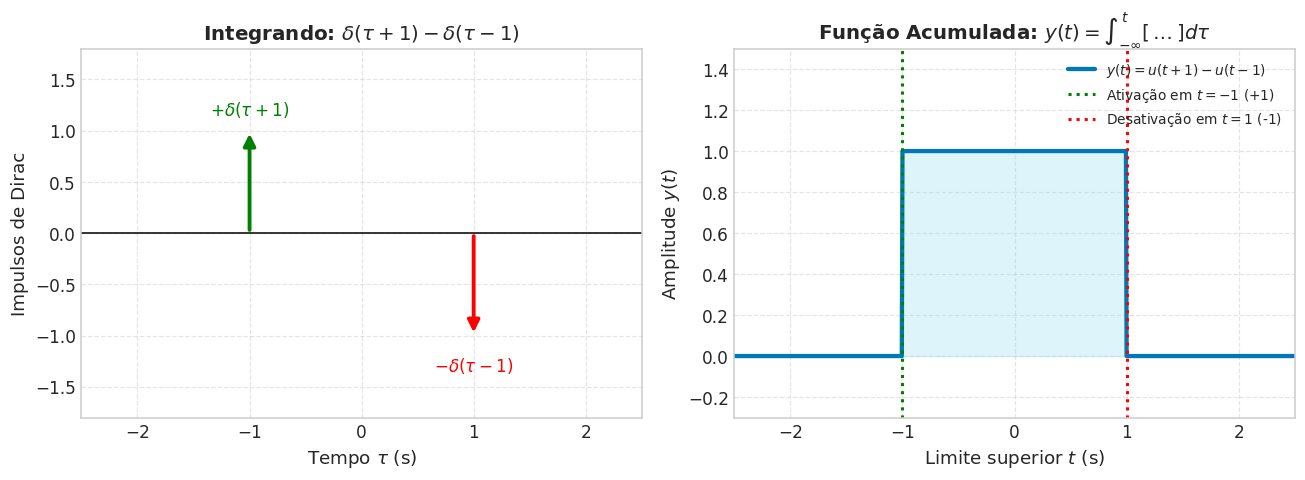

In [17]:
# Visualização Gráfica Completa da Alínea o: Impulsos vs Função Acumulada y(t)
t_vec_o = np.linspace(-3, 3, 1000)
y_accum = ((t_vec_o >= -1.0) & (t_vec_o < 1.0)).astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Integrando: Impulsos de Dirac
ax1.axhline(0, color='black', lw=1.0)
ax1.annotate('', xy=(-1, 1), xytext=(-1, 0), arrowprops=dict(arrowstyle="-|>", color='green', lw=2.5, mutation_scale=16))
ax1.annotate('', xy=(1, -1), xytext=(1, 0), arrowprops=dict(arrowstyle="-|>", color='red', lw=2.5, mutation_scale=16))
ax1.text(-1, 1.15, r'$+\delta(\tau+1)$', color='green', ha='center', fontweight='bold')
ax1.text(1, -1.35, r'$-\delta(\tau-1)$', color='red', ha='center', fontweight='bold')
ax1.set_title(r'Integrando: $\delta(\tau+1) - \delta(\tau-1)$', fontweight='bold')
ax1.set_xlabel(r'Tempo $\tau$ (s)')
ax1.set_ylabel('Impulsos de Dirac')
ax1.set_ylim(-1.8, 1.8)
ax1.set_xlim(-2.5, 2.5)

# 2. Função Acumulada y(t) = u(t+1) - u(t-1)
ax2.plot(t_vec_o, y_accum, color='#0077b6', lw=2.8, label=r'$y(t) = u(t+1) - u(t-1)$')
ax2.fill_between(t_vec_o, y_accum, color='#90e0ef', alpha=0.3)
ax2.axvline(-1, color='green', linestyle=':', label=r'Ativação em $t=-1$ (+1)')
ax2.axvline(1, color='red', linestyle=':', label=r'Desativação em $t=1$ (-1)')
ax2.set_title(r'Função Acumulada: $y(t) = \int_{-\infty}^{t}[\dots]d\tau$', fontweight='bold')
ax2.set_xlabel(r'Limite superior $t$ (s)')
ax2.set_ylabel(r'Amplitude $y(t)$')
ax2.set_ylim(-0.3, 1.5)
ax2.set_xlim(-2.5, 2.5)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## Síntese Pedagógica e Resumo de Fórmulas

| Conceito / Operação | Expressão Matemática | Propriedade Física / Engenharia |
| :--- | :--- | :--- |
| **Avanço Temporal** | $x(t + t_0), \; t_0 > 0$ | Translação para a esquerda ($t_{novo} = t_{antigo} - t_0$). |
| **Atraso Temporal** | $x(t - t_0), \; t_0 > 0$ | Translação para a direita ($t_{novo} = t_{antigo} + t_0$). |
| **Compressão / Expansão** | $x(at)$ | $|a| > 1$: Compressão; $|a| < 1$: Expansão temporal. |
| **Decimação Discreta** | $x[Mn], \; M \in \mathbb{Z}^+$ | Perda irreparável de amostras não múltiplas de $M$. |
| **Derivada do Degrau** | $\frac{d}{dt} u(t-t_0) = \delta(t-t_0)$ | Modelação de transições instantâneas de tensão / estado. |
| **Integral do Degrau** | $\int_{-\infty}^t u(\tau-t_0) d\tau = r(t-t_0)$ | Função rampa unitária $r(t-t_0) = (t-t_0)u(t-t_0)$. |
| **Amostragem do Impulso** | $\int_{-\infty}^{\infty} f(t)\delta(t-t_0)dt = f(t_0)$ | Valor instantâneo do sinal contínuo no suporte do impulso. |
| **Integral Definido vs Função** | $\int_{-\infty}^{\infty} \delta(\tau)d\tau = 1 \quad\text{vs}\quad \int_{-\infty}^t \delta(\tau)d\tau = u(t)$ | Valor escalar da área total vs função degrau no tempo. |

---
**Fim do Notebook Prático — TP03**  
*ISEP / DEE — Sinais e Sistemas*
